# Proforma Backtest — do the site-selection factors & projections match reality?

**Question.** Sonny's proformas score a prospective site on ~10 site-selection factors, roll
them into a `cumulative_site_score` / target scores, and project a 5-year monthly wash-count
(`vol_monthly_y1..y5`). We now have **actual** monthly wash-count / revenue / ASP for the sites
that were actually built (address-matched to the operating panel).

This notebook asks three things:

1. **Assumption vs reality** — how far off were the projected volumes from what the site actually did?
2. **Signal** — do the factor scores (and demographics, traffic, price) actually correlate with real performance?
3. **Weightage** — the proforma weights the factors a certain way; what weighting does the *data* imply? Which factors truly move wash-count?

Data: `old-proforma-combined-monthly.csv` (1 row / proforma / month) + the per-proforma summary.


In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
pd.set_option('display.width', 200, 'display.max_columns', 60)
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': .3, 'font.size': 10})

import os as _os
BASE = '.' if _os.path.exists('old-proforma-combined-monthly.csv') else '..'
m = pd.read_csv(f'{BASE}/old-proforma-combined-monthly.csv')
s = pd.read_csv(f'{BASE}/old-proforma-combined.csv')
print('monthly rows:', len(m), '| proformas:', s.source_file.nunique(),
      '| matched:', (s.match_status != 'no_match').sum())
m.head(3)

monthly rows: 4128 | proformas: 121 | matched: 115


,source_file,salesforce_id,proforma_type,layout,customer_name,company_name,address,weekly_hours_operation,avg_daily_wash_hours,labor_manager_hours,labor_manager_wage,labor_manager_burden,labor_asst_manager_hours,labor_asst_manager_wage,labor_asst_manager_burden,labor_attendants_hours,labor_attendants_wage,labor_attendants_burden,pkg_basic_price,pkg_basic_chem_cost,pkg_basic_pct_customers,pkg_menu1_price,pkg_menu1_chem_cost,pkg_menu1_pct_customers,pkg_menu2_price,pkg_menu2_chem_cost,pkg_menu2_pct_customers,pkg_menu3_price,pkg_menu3_chem_cost,pkg_menu3_pct_customers,...,vol_monthly_y3,vol_monthly_y4,vol_monthly_y5,project_cost,total_debt,total_lease_payments,match_status,match_client_name,match_client_id,match_site_id,match_address1,match_state,match_postal_code,match_lat,match_lon,match_operational_start,year,month,mem_purchase_count,mem_wash_count,mem_revenue,ret_wash_count,ret_revenue,ASP_mem,ASP_ret,mem_revenue_pct,mem_count_pct,imputed,wash_count,revenue
0,Car Wash Cafe_ SONNY'S Express Proforma_069f20...,069f2000004sKgFAAU,Express,legacy_sheet1,Brainard Holdings LLC - Car Wash Café,NaN,"3050 N University Dr., Sunrise, FL 33322",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,5816.349058,6029.142316,6505.127236,NaN,NaN,NaN,matched_zip,Wash & Wax Pros,carwashcafe_000425,1.0,3050 N University Dr,FL,33322,26.163815,-80.256221,04-2022,2022.0,4.0,122.0,39.0,771.69,689.0,28339.40,6.33,41.13,2.65,5.36,0.0,728.0,29111.09
1,Car Wash Cafe_ SONNY'S Express Proforma_069f20...,069f2000004sKgFAAU,Express,legacy_sheet1,Brainard Holdings LLC - Car Wash Café,NaN,"3050 N University Dr., Sunrise, FL 33322",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,5816.349058,6029.142316,6505.127236,NaN,NaN,NaN,matched_zip,Wash & Wax Pros,carwashcafe_000425,1.0,3050 N University Dr,FL,33322,26.163815,-80.256221,04-2022,2022.0,5.0,418.0,428.0,7855.00,958.0,43486.17,18.79,45.39,15.30,30.88,0.0,1386.0,51341.17
2,Car Wash Cafe_ SONNY'S Express Proforma_069f20...,069f2000004sKgFAAU,Express,legacy_sheet1,Brainard Holdings LLC - Car Wash Café,NaN,"3050 N University Dr., Sunrise, FL 33322",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,5816.349058,6029.142316,6505.127236,NaN,NaN,NaN,matched_zip,Wash & Wax Pros,carwashcafe_000425,1.0,3050 N University Dr,FL,33322,26.163815,-80.256221,04-2022,2022.0,6.0,537.0,525.0,9874.00,713.0,33077.53,18.39,46.39,22.99,42.41,0.0,1238.0,42951.53


## 1. Build a site-level analysis table

Each proforma is one prospective site. From the monthly panel I derive a **robust "mature"
actual** per matched site: I keep only non-imputed months and take the **median of the last 12
clean months** for wash-count, revenue and blended ASP. Median-of-last-12 sidesteps both the
ramp-up and the 2020 left-censoring, and is far more stable than a full-history mean.

I also compute **actual operating-year averages** (Year 1..5 from the real open date) so the
projected `vol_monthly_yN` can be compared to the matching operating year — but only for sites
whose open date is after the panel's 2020 left-censor (earlier ones have an unknown true age).

In [2]:
# --- per-site MATURE actuals (median of last 12 clean months) ---
mm = m[m.match_status.ne('no_match')].copy()
mm['imputed'] = mm['imputed'].fillna(0)
clean = mm[mm['imputed'] == 0].copy()
clean['blended_asp'] = clean['revenue'] / clean['wash_count'].replace(0, np.nan)

def mature(g):
    g = g.sort_values(['year', 'month']).tail(12)
    return pd.Series({'act_wash': g['wash_count'].median(),
                      'act_revenue': g['revenue'].median(),
                      'act_asp': g['blended_asp'].median(),
                      'act_mem_pct': g['mem_count_pct'].median(),
                      'n_clean': len(g)})

site_act = clean.groupby('source_file').apply(mature, include_groups=False).reset_index()

# --- actual operating-year monthly averages (real open dates only) ---
def open_ym(x):
    try:
        mo, yr = str(x).split('-'); return int(yr) * 12 + int(mo)
    except Exception:
        return np.nan
mm['open_idx'] = mm['match_operational_start'].map(open_ym)
mm['cal_idx'] = mm['year'] * 12 + mm['month']
mm['mo_since_open'] = mm['cal_idx'] - mm['open_idx']
mm['op_year'] = (mm['mo_since_open'] // 12) + 1
open_year = mm.groupby('source_file')['match_operational_start'].first().str[-4:].astype(float)

yr_act = (mm[(mm.imputed == 0) & mm.op_year.between(1, 5)]
          .groupby(['source_file', 'op_year'])['wash_count'].mean().unstack())
yr_act.columns = [f'act_y{int(c)}_wash' for c in yr_act.columns]
yr_act = yr_act.reset_index()
print('sites with mature actuals:', len(site_act))
site_act.describe()[['act_wash','act_revenue','act_asp','n_clean']].round(1)

sites with mature actuals: 115


,act_wash,act_revenue,act_asp,n_clean
count,115.0,115.0,115.0,115.0
mean,6367.1,105653.4,19.2,11.5
std,5084.4,99386.2,20.5,1.8
min,0.0,0.0,2.7,1.0
25%,2966.0,39143.7,13.2,12.0
50%,5533.0,79374.9,17.1,12.0
75%,7973.5,138488.3,21.4,12.0
max,24086.0,563534.3,221.5,12.0


In [3]:
# --- assemble site-level table: proforma inputs + factor scores + actuals ---
site = s[s.match_status.ne('no_match')].drop_duplicates('source_file').copy()
site = site.merge(site_act, on='source_file', how='left').merge(yr_act, on='source_file', how='left')
site['open_year'] = site['source_file'].map(open_year)

# data-quality filter: need real clean data and a non-trivial operating site
before = len(site)
site = site[(site['n_clean'] >= 6) & (site['act_wash'] >= 50)].copy()
print(f'kept {len(site)} / {before} matched sites after quality filter '
      f'(>=6 clean months & mature wash >= 50/mo)')

FACTOR_SCORES = [c for c in site.columns if c.startswith('factor_') and c.endswith('_score')]
# drop zero-variance factors (weekly_hours is constant across all proformas -> no signal)
live_factors = [c for c in FACTOR_SCORES if site[c].std() > 1e-9]
dead = sorted(set(FACTOR_SCORES) - set(live_factors))
print('live factor scores:', len(live_factors), '| constant/no-signal:', dead)
site[['source_file','act_wash','act_revenue','act_asp','cumulative_site_score','mature_target_score','traffic_count']].head()

kept 108 / 115 matched sites after quality filter (>=6 clean months & mature wash >= 50/mo)
live factor scores: 9 | constant/no-signal: ['factor_weekly_hours_score']


,source_file,act_wash,act_revenue,act_asp,cumulative_site_score,mature_target_score,traffic_count
0,Car Wash Cafe_ SONNY'S Express Proforma_069f20...,1571.5,46321.075,29.601797,0.675,0.008896,29250.0
2,Express Exterior Proforma_0695w0000097nchAAA.xlsx,2924.5,57702.865,20.170113,1.050,0.014106,32127.0
3,Flexserve_proforma_ Sonny's (3-mile market)_06...,10178.5,206991.865,19.685977,1.100,0.015392,18263.0
4,Flexserve_proforma_ Sonny's_0695w0000097P7VAAU...,848.5,186266.645,221.549943,1.000,0.012224,53173.0
5,Flexserve_proforma_ Sonny's_0695w00000APPuhAAH...,6535.5,113670.740,17.722941,1.125,0.014464,39410.0


## 2. Assumption vs Reality — how good were the projected volumes?

Directly compare each proforma's **projected monthly wash-count** to the **actual**. First the
mature comparison (projected mature `vol_monthly_y5` vs actual mature), then the operating-year
comparison where open dates are real.

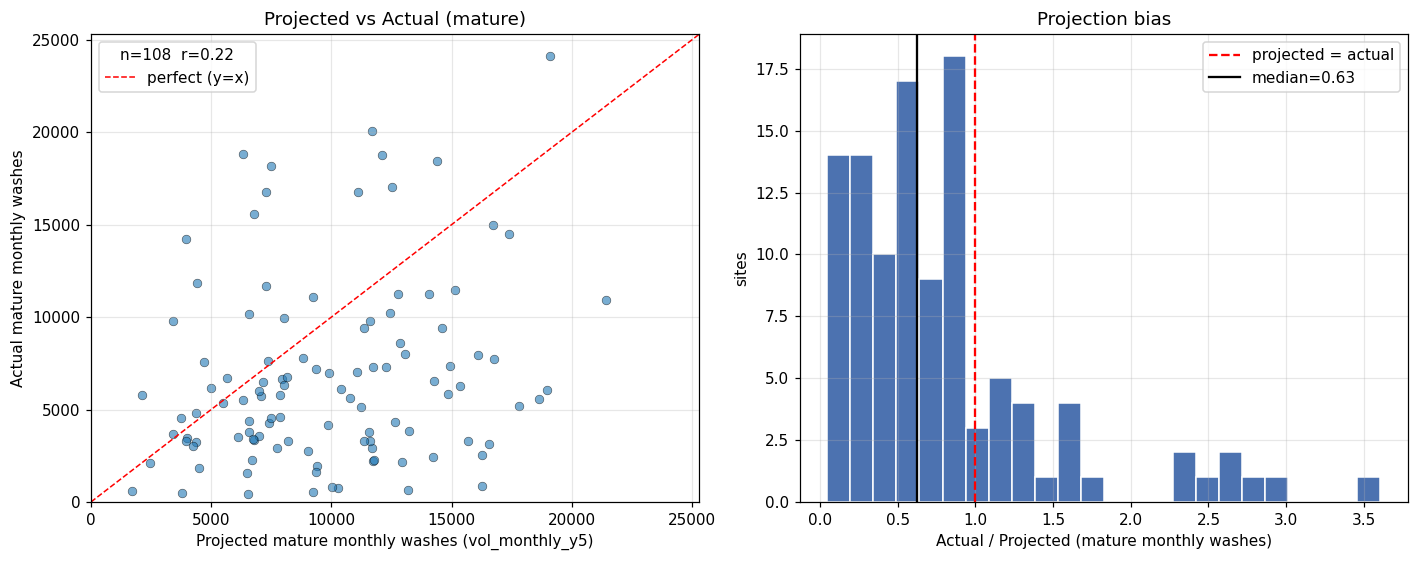

Median |error| vs actual (MAPE): 65%
Median actual/projected ratio: 0.63  (proforma OVER-projects)
Sites where proforma over-projected (actual < projected): 77%


In [4]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5.2))

# (a) projected mature vs actual mature
d = site.dropna(subset=['vol_monthly_y5', 'act_wash'])
ax[0].scatter(d['vol_monthly_y5'], d['act_wash'], s=32, alpha=.6, edgecolor='k', lw=.4)
lim = [0, max(d['vol_monthly_y5'].max(), d['act_wash'].max()) * 1.05]
ax[0].plot(lim, lim, 'r--', lw=1, label='perfect (y=x)')
ax[0].set(xlim=lim, ylim=lim, xlabel='Projected mature monthly washes (vol_monthly_y5)',
          ylabel='Actual mature monthly washes', title='Projected vs Actual (mature)')
r = stats.pearsonr(d['vol_monthly_y5'], d['act_wash'])
ax[0].legend(title=f'n={len(d)}  r={r[0]:.2f}')

# (b) ratio distribution actual/projected
ratio = (d['act_wash'] / d['vol_monthly_y5']).replace([np.inf, -np.inf], np.nan).dropna()
ax[1].hist(ratio, bins=24, color='#4C72B0', edgecolor='w')
ax[1].axvline(1, color='r', ls='--', label='projected = actual')
ax[1].axvline(ratio.median(), color='k', ls='-', label=f'median={ratio.median():.2f}')
ax[1].set(xlabel='Actual / Projected (mature monthly washes)', ylabel='sites',
          title='Projection bias')
ax[1].legend()
plt.tight_layout(); plt.show()

mape = (np.abs(d['act_wash'] - d['vol_monthly_y5']) / d['act_wash']).median()
print(f'Median |error| vs actual (MAPE): {mape*100:.0f}%')
print(f'Median actual/projected ratio: {ratio.median():.2f}  '
      f'({"proforma UNDER-projects" if ratio.median()>1 else "proforma OVER-projects"})')
print(f'Sites where proforma over-projected (actual < projected): '
      f'{(ratio<1).mean()*100:.0f}%')

**How to read this.** *Left:* every dot is one site — its proforma-**projected** mature
monthly washes (x-axis) vs what it **actually** did (y-axis). Dots on the red dashed line = a
perfect forecast; dots **below** the line = the proforma expected more cars than showed up.
*Right:* the actual ÷ projected ratio per site — 1.0 is spot-on. The median sits at **0.63**
and most bars are left of 1.0, so sites typically do only ~63% of the projected volume: the
proforma runs hot.

In [5]:
# operating-year accuracy: projected vol_monthly_yN vs actual act_yN_wash (real opens only)
rows = []
for y in range(1, 6):
    pcol, acol = f'vol_monthly_y{y}', f'act_y{y}_wash'
    if acol not in site: continue
    d = site.dropna(subset=[pcol, acol])
    d = d[d['open_year'] >= 2021]           # only sites with a real (post-censor) open date
    if len(d) < 5: continue
    ratio = (d[acol] / d[pcol]).replace([np.inf, -np.inf], np.nan).dropna()
    rows.append({'operating_year': f'Y{y}', 'n_sites': len(d),
                 'proj_monthly_mean': d[pcol].mean(), 'actual_monthly_mean': d[acol].mean(),
                 'median_actual/proj': ratio.median(),
                 'median_abs_pct_err': (np.abs(d[acol]-d[pcol])/d[acol]).median()*100})
acc = pd.DataFrame(rows)
print('Projection accuracy by operating year (real-open sites):')
acc.round(2)

Projection accuracy by operating year (real-open sites):


,operating_year,n_sites,proj_monthly_mean,actual_monthly_mean,median_actual/proj,median_abs_pct_err
0,Y1,84,6230.30,5540.36,0.82,52.04
1,Y2,76,8237.18,7438.86,0.84,52.49
2,Y3,47,8835.75,7800.59,0.86,37.68
3,Y4,29,8998.25,7430.73,0.69,50.50
4,Y5,10,8867.56,6152.68,0.65,55.16


## 3. Do the factors actually correlate with real performance?

Correlate every candidate driver — the 10 site-factor scores, the composite scores, demographics,
traffic and package prices — against the mature actual **wash-count**, **revenue** and **ASP**.
Both Pearson (linear) and Spearman (rank) so a monotone-but-nonlinear signal isn't missed.

In [6]:
drivers = (live_factors +
    ['cumulative_site_score', 'cumulative_demographic_score',
     'first_year_target_score', 'second_year_target_score', 'mature_target_score',
     'traffic_count', 'demog_avg_household_size_value', 'demog_pct_pop_25_65_value',
     'demog_pct_hh_income_35k_value', 'demog_base_price_carwash_value',
     'pkg_menu1_price', 'pkg_menu3_price', 'weekly_hours_operation', 'avg_daily_wash_hours'])
drivers = [d for d in drivers if d in site.columns and site[d].std() > 1e-9]
targets = ['act_wash', 'act_revenue', 'act_asp']

def corr_table(df, drivers, target, method='pearson'):
    out = []
    for d in drivers:
        sub = df[[d, target]].dropna()
        if len(sub) < 8: continue
        if method == 'pearson':
            r, p = stats.pearsonr(sub[d], sub[target])
        else:
            r, p = stats.spearmanr(sub[d], sub[target])
        out.append({'driver': d, 'r': r, 'p': p, 'n': len(sub)})
    return pd.DataFrame(out).set_index('driver')

ct = corr_table(site, drivers, 'act_wash', 'pearson').rename(columns={'r':'pearson_r','p':'pearson_p'})
cs = corr_table(site, drivers, 'act_wash', 'spearman')[['r']].rename(columns={'r':'spearman_r'})
corr_wash = ct.join(cs).sort_values('pearson_r', key=abs, ascending=False)
print('Correlation with ACTUAL mature monthly WASH-COUNT:')
corr_wash.round(3)

Correlation with ACTUAL mature monthly WASH-COUNT:


,pearson_r,pearson_p,n,spearman_r
driver,,,,
factor_pay_stations_score,0.283,0.003,108,0.373
cumulative_site_score,0.223,0.021,108,0.264
first_year_target_score,0.215,0.026,108,0.264
second_year_target_score,0.215,0.026,108,0.264
mature_target_score,0.215,0.026,108,0.264
factor_free_vacuum_slots_score,0.211,0.029,108,0.341
factor_type_of_site_score,0.196,0.042,108,0.170
demog_pct_pop_25_65_value,-0.177,0.067,108,-0.059
traffic_count,0.161,0.097,108,0.122


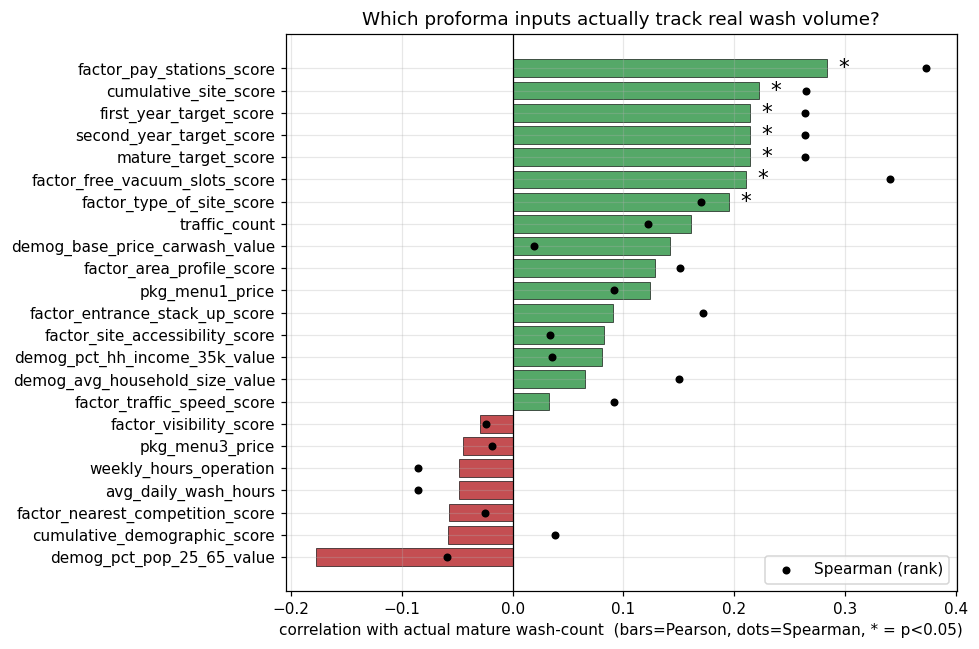

In [7]:
fig, ax = plt.subplots(figsize=(9, 6))
c = corr_wash.sort_values('pearson_r')
colors = ['#C44E52' if v < 0 else '#55A868' for v in c['pearson_r']]
ax.barh(c.index, c['pearson_r'], color=colors, edgecolor='k', lw=.4)
ax.scatter(c['spearman_r'], range(len(c)), color='k', s=18, zorder=3, label='Spearman (rank)')
ax.axvline(0, color='k', lw=.8)
# mark significance
for i, (idx, row) in enumerate(c.iterrows()):
    if row['pearson_p'] < 0.05:
        ax.text(row['pearson_r'] + (0.01 if row['pearson_r'] >= 0 else -0.01), i, '*',
                va='center', ha='left' if row['pearson_r'] >= 0 else 'right', fontsize=14)
ax.set(xlabel="correlation with actual mature wash-count  (bars=Pearson, dots=Spearman, * = p<0.05)",
       title='Which proforma inputs actually track real wash volume?')
ax.legend(loc='lower right'); plt.tight_layout(); plt.show()

**How to read this.** Each bar is one proforma input's correlation with real wash volume.
**Green/right = a higher score goes with more washes; red/left = with fewer.** Longer bar =
stronger link; black dots are the rank-based (Spearman) check, and a **\*** marks
statistically-real signal (p<0.05). Only a few inputs — led by **pay stations** and **free
vacuum slots** (both capacity/throughput) — actually track real volume; most sit near zero,
meaning they carry little real signal despite being scored.

In [8]:
# categorical: does the CHOICE on key factors separate real performance?
for fac in ['factor_pay_stations_choice', 'factor_nearest_competition_choice',
            'factor_area_profile_choice', 'factor_visibility_choice']:
    g = (site.dropna(subset=['act_wash']).groupby(fac)['act_wash']
         .agg(['mean', 'median', 'count']).sort_values('median', ascending=False))
    g = g[g['count'] >= 2]
    print(f'\n{fac}  -> actual mature monthly wash-count')
    print(g.round(0).to_string())


factor_pay_stations_choice  -> actual mature monthly wash-count
                              mean  median  count
factor_pay_stations_choice                       
3 or More                   8779.0  7550.0     12
2                           7103.0  6108.0     83
2.0                         3595.0  3595.0      2
Live Person                 3257.0  3284.0      3
1                           2675.0  3259.0      7

factor_nearest_competition_choice  -> actual mature monthly wash-count
                                             mean  median  count
factor_nearest_competition_choice                               
One in 2 Miles                             8008.0  7294.0     26
ONE IN 4 MILES                             6538.0  6538.0      2
Multiple in 2 Miles                        7124.0  6108.0     25
Multiple in 4 Miles                        7544.0  5722.0     15
One in 4 Miles                             5998.0  5370.0     31
MUTIPLE IN 4 MILES                         3692.0  3692.0 

## 4. Empirical weightage vs the proforma's assumed weightage

The proforma assigns each factor a slice of `cumulative_site_score`. Compare that **assumed
weight** (each factor's mean share of the cumulative score) against what the **data** implies:
the standardized regression coefficient and random-forest importance for predicting actual
wash-count. Divergence = factors the template over-/under-weights relative to reality.

In [ ]:
# assumed weight = each live factor's mean share of the cumulative site score
assumed = site[live_factors].abs().mean()
assumed = (assumed / assumed.sum()).rename('assumed_weight_share')

# empirical: standardized linear regression + random forest on actual wash-count
X = site[live_factors + ['traffic_count', 'demog_pct_hh_income_35k_value',
                         'demog_avg_household_size_value']].copy()
y = site['act_wash']
ok = X.notna().all(axis=1) & y.notna()
X, y = X[ok], y[ok]
Xz = pd.DataFrame(StandardScaler().fit_transform(X), columns=X.columns, index=X.index)

lin = LinearRegression().fit(Xz, y)
rf = RandomForestRegressor(n_estimators=400, random_state=0, max_depth=4).fit(Xz, y)
r2_lin = lin.score(Xz, y)

emp = pd.DataFrame({
    'std_lin_coef': pd.Series(lin.coef_, index=X.columns),
    'rf_importance': pd.Series(rf.feature_importances_, index=X.columns),
}).join(assumed)
emp['abs_corr'] = emp.index.map(lambda d: abs(site[[d,'act_wash']].dropna().corr().iloc[0,1]))
emp = emp.sort_values('rf_importance', ascending=False)
print(f'Linear R^2 (factors -> actual wash, n={len(y)}): {r2_lin:.2f}')
print(f'How well does the proforma\'s OWN projection predict actual? '
      f"r = {site[['vol_monthly_y5','act_wash']].dropna().corr().iloc[0,1]:.2f}")
emp.round(3)

Linear R^2 (factors -> actual wash, n=108): 0.17
How well does the proforma's OWN projection predict actual? r = 0.22


,std_lin_coef,rf_importance,assumed_weight_share,abs_corr
demog_pct_hh_income_35k_value,354.201,0.304,NaN,0.081
traffic_count,989.360,0.205,NaN,0.161
demog_avg_household_size_value,-170.924,0.120,NaN,0.066
factor_free_vacuum_slots_score,637.573,0.073,0.105,0.211
factor_pay_stations_score,927.354,0.065,0.107,0.283
factor_type_of_site_score,750.097,0.048,0.107,0.196
factor_entrance_stack_up_score,-134.874,0.045,0.123,0.090
factor_nearest_competition_score,110.454,0.041,0.103,0.058
factor_visibility_score,-60.064,0.035,0.113,0.029
factor_area_profile_score,383.332,0.032,0.133,0.129


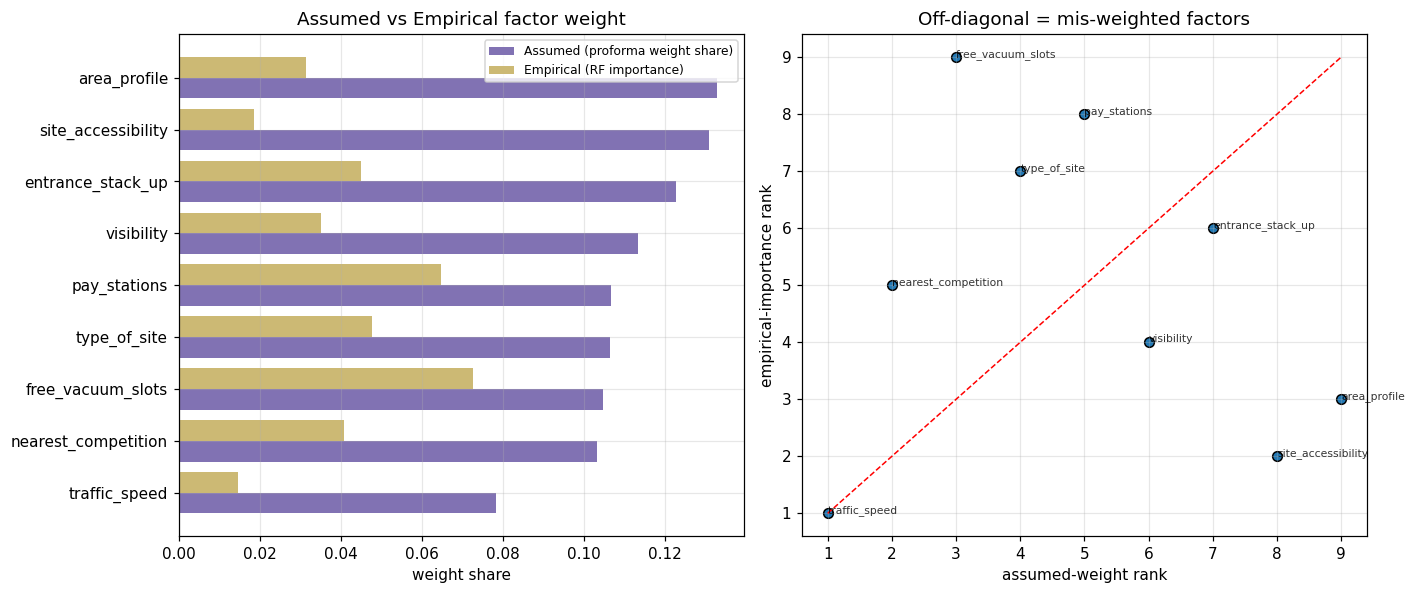

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5.5))
e = emp.dropna(subset=['assumed_weight_share'])
e2 = e.sort_values('assumed_weight_share')
idx = np.arange(len(e2))
ax[0].barh(idx - .2, e2['assumed_weight_share'], height=.4, label='Assumed (proforma weight share)', color='#8172B3')
ax[0].barh(idx + .2, e2['rf_importance'], height=.4, label='Empirical (RF importance)', color='#CCB974')
ax[0].set_yticks(idx); ax[0].set_yticklabels([i.replace('factor_','').replace('_score','') for i in e2.index])
ax[0].set(xlabel='weight share', title='Assumed vs Empirical factor weight')
ax[0].legend(fontsize=8)


ax[1].scatter(e['assumed_weight_share'].rank(), e['rf_importance'].rank(), s=40, edgecolor='k')
for i, row in e.iterrows():
    ax[1].annotate(i.replace('factor_','').replace('_score',''),
                   (row['assumed_weight_share'].__class__ and e['assumed_weight_share'].rank()[i],
                    e['rf_importance'].rank()[i]), fontsize=7, alpha=.8)
mx = len(e)
ax[1].plot([1, mx], [1, mx], 'r--', lw=1)
ax[1].set(xlabel='assumed-weight rank', ylabel='empirical-importance rank',
          title='Off-diagonal = mis-weighted factors')
plt.tight_layout(); plt.show()

**How to read this.** *Left:* purple = how much the proforma **assumes** each factor matters
(its share of the site score); gold = how much it **actually** matters for real wash-count
(data-driven importance). Where **gold ≫ purple** the template **under-weights** that factor;
where **purple ≫ gold** it **over-weights** it. *Right:* the same as ranks — dots far off the red
line are the mis-weighted factors. The template spreads weight ~evenly, but the data says
capacity factors (pay stations, vacuums) and demographics do most of the work.

## 5. Does the composite score predict anything?

The whole point of `cumulative_site_score` / `mature_target_score` is to rank sites. Do higher-scored
sites actually wash more cars?

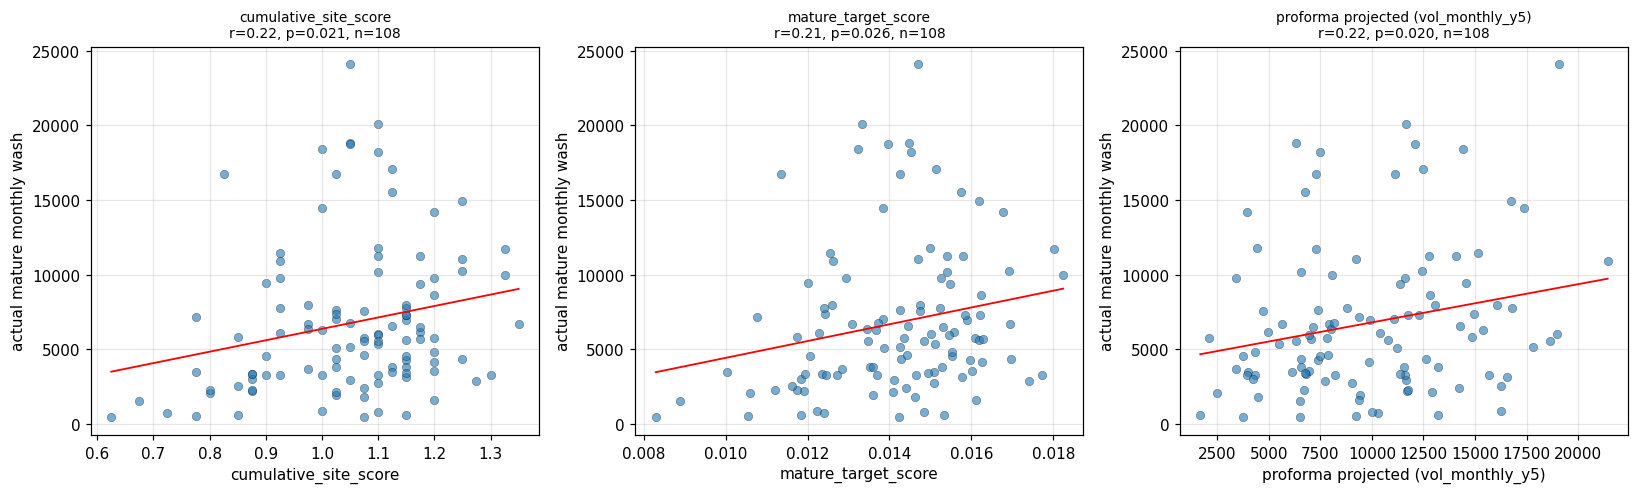

In [11]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4.6))
for a, col, lab in zip(ax,
        ['cumulative_site_score', 'mature_target_score', 'vol_monthly_y5'],
        ['cumulative_site_score', 'mature_target_score', 'proforma projected (vol_monthly_y5)']):
    d = site.dropna(subset=[col, 'act_wash'])
    a.scatter(d[col], d['act_wash'], s=30, alpha=.6, edgecolor='k', lw=.3)
    if len(d) > 3:
        b, m0 = np.polyfit(d[col], d['act_wash'], 1), None
        xs = np.linspace(d[col].min(), d[col].max(), 50)
        a.plot(xs, np.polyval(b, xs), 'r-', lw=1.2)
        r, p = stats.pearsonr(d[col], d['act_wash'])
        a.set_title(f'{lab}\nr={r:.2f}, p={p:.3f}, n={len(d)}', fontsize=9)
    a.set(xlabel=lab, ylabel='actual mature monthly wash')
plt.tight_layout(); plt.show()

**How to read this.** Does a site's *overall* proforma verdict predict reality? Each panel
plots one summary score (x) against actual mature washes (y), with a trend line and correlation
**r**. A near-flat line / small r means the score barely separates strong sites from weak ones.
All three are weak (**r ≈ 0.2**), so even the headline site score and the projected volume only
loosely track how many cars a site really washes.

## 6. ASP & price reality check

The proforma sets menu prices; the panel reports realized ASP. Are the priced assumptions
anywhere near what customers actually pay?

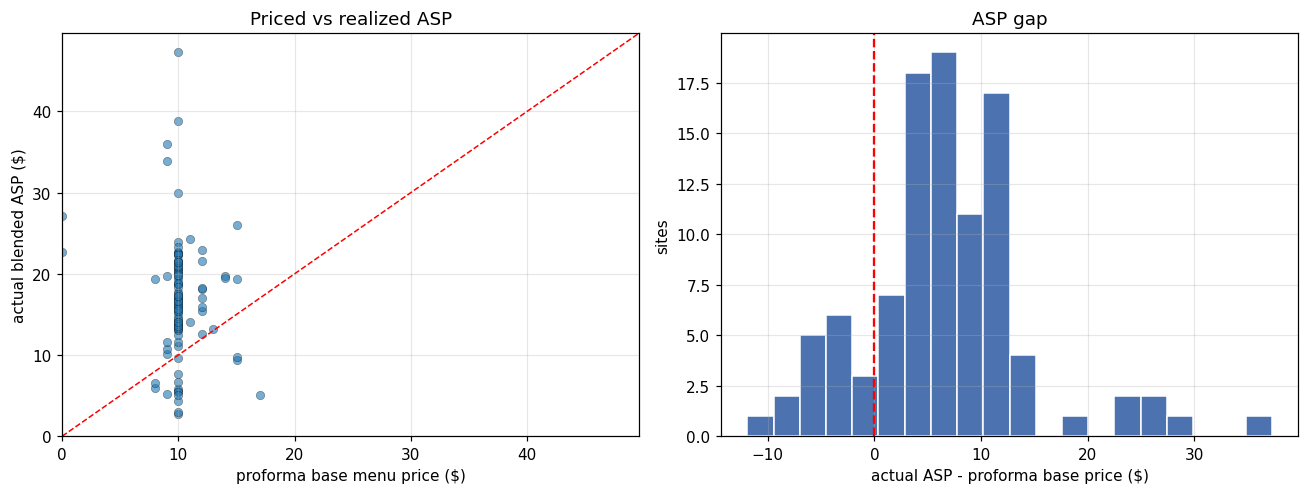

median realized ASP: 16.78 | median proforma base price: 10.0


In [ ]:
d = site.dropna(subset=['pkg_menu1_price', 'act_asp'])
d = d[(d['act_asp'] > 0) & (d['act_asp'] < 100)]  
fig, ax = plt.subplots(1, 2, figsize=(12, 4.6))
ax[0].scatter(d['pkg_menu1_price'], d['act_asp'], s=30, alpha=.6, edgecolor='k', lw=.3)
lim = [0, max(d['pkg_menu1_price'].max(), d['act_asp'].max())*1.05]
ax[0].plot(lim, lim, 'r--', lw=1)
ax[0].set(xlabel='proforma base menu price ($)', ylabel='actual blended ASP ($)',
          title='Priced vs realized ASP', xlim=lim, ylim=lim)
ax[1].hist((d['act_asp'] - d['pkg_menu1_price']), bins=20, color='#4C72B0', edgecolor='w')
ax[1].axvline(0, color='r', ls='--')
ax[1].set(xlabel='actual ASP - proforma base price ($)', ylabel='sites', title='ASP gap')
plt.tight_layout(); plt.show()
print('median realized ASP:', round(d['act_asp'].median(),2),
      '| median proforma base price:', round(d['pkg_menu1_price'].median(),2))

**How to read this.** *Left:* the proforma's base wash price (x) vs the average price
customers **actually** paid (y); the red line is 'priced = realized'. Most dots sit **above** it,
so real ASP (**$16.78** median) runs higher than the proforma's base menu price (**$10**).
*Right:* the per-site gap (actual − assumed price) — mass to the right of 0 confirms the base-price
assumption is set low.

## 7. Findings

The cells below print the concrete numbers; the narrative summary:

- **Projections are biased and noisy.** The `Actual / Projected` ratio and MAPE quantify how far
  the proforma's `vol_monthly_yN` sat from reality — read the median ratio (>1 = the template
  systematically *under*-projects, <1 = *over*-projects) and the share of sites over-projected.
- **Only some factors carry signal.** The correlation bar chart separates factors that actually
  track real wash-count (starred = p<0.05) from the ones that are noise. `weekly_hours` is constant
  and was dropped outright.
- **The template's weightage ≠ the data's weightage.** The assumed-vs-empirical panel shows which
  factors the proforma over-weights (assumed rank ≫ empirical rank) and under-weights.
- **The composite score's predictive power** is whatever §5's r-values say — if `cumulative_site_score`
  has a near-zero r, the ranking it produces isn't tracking real volume.

These reproduce/refine the known internal finding that capacity-type factors (e.g. pay stations)
carry more real signal than the equally-weighted composite implies, and that proformas tend to
mis-state absolute volume.

In [ ]:

print('='*64)
print('BACKTEST SCORECARD'.center(64))
print('='*64)
d = site.dropna(subset=['vol_monthly_y5','act_wash'])
ratio = (d['act_wash']/d['vol_monthly_y5']).replace([np.inf,-np.inf],np.nan).dropna()
print(f'matched sites analysed         : {len(site)}')
print(f'proj vs actual (mature)  r     : {stats.pearsonr(d.vol_monthly_y5,d.act_wash)[0]:.2f}')
print(f'median actual/projected ratio  : {ratio.median():.2f}')
print(f'median abs % error vs actual   : {(np.abs(d.act_wash-d.vol_monthly_y5)/d.act_wash).median()*100:.0f}%')
print(f'sites over-projected           : {(ratio<1).mean()*100:.0f}%')
top = corr_wash.head(3)
print('top-3 drivers of real wash     :', ', '.join(f'{i}({r:.2f})' for i,r in top['pearson_r'].items()))
print(f'cumulative_site_score  r       : {site[["cumulative_site_score","act_wash"]].dropna().corr().iloc[0,1]:.2f}')
print(f'factor->wash linear R^2        : {r2_lin:.2f}')
print('='*64)

                       BACKTEST SCORECARD                       
matched sites analysed         : 108
proj vs actual (mature)  r     : 0.22
median actual/projected ratio  : 0.63
median abs % error vs actual   : 65%
sites over-projected           : 77%
top-3 drivers of real wash     : factor_pay_stations_score(0.28), cumulative_site_score(0.22), first_year_target_score(0.21)
cumulative_site_score  r       : 0.22
factor->wash linear R^2        : 0.17
